In [30]:
! pip install pandas numpy matplotlib seaborn scikit-learn scipy xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [32]:
def simulate_data_with_anomalies(size=1000, anomaly_fraction=0.05):
    np.random.seed(42)
    
    normal_size = int(size * (1 - anomaly_fraction))
    anomaly_size = size - normal_size
    
    normal_data = {
        'A_Current_mean': np.random.normal(100, 10, normal_size),
        'A_Current_std': np.random.normal(5, 1, normal_size),
        'A_Voltage_mean': np.random.normal(220, 20, normal_size),
        'A_Voltage_std': np.random.normal(10, 2, normal_size),
        'B_Current_mean': np.random.normal(95, 12, normal_size),
        'B_Current_std': np.random.normal(6, 1.2, normal_size),
        'B_Voltage_mean': np.random.normal(215, 18, normal_size),
        'B_Voltage_std': np.random.normal(9, 1.8, normal_size),
        'A_Impedance': np.random.normal(2.2, 0.2, normal_size),
        'B_Impedance': np.random.normal(2.25, 0.22, normal_size),
        'is_anomaly': np.zeros(normal_size)
    }
    
    anomaly_data = {
        'A_Current_mean': np.random.normal(130, 15, anomaly_size), 
        'A_Current_std': np.random.normal(12, 3, anomaly_size),    
        'A_Voltage_mean': np.random.normal(180, 25, anomaly_size), 
        'A_Voltage_std': np.random.normal(20, 5, anomaly_size),    
        'B_Current_mean': np.random.normal(125, 18, anomaly_size), 
        'B_Current_std': np.random.normal(15, 4, anomaly_size),    
        'B_Voltage_mean': np.random.normal(175, 22, anomaly_size), 
        'B_Voltage_std': np.random.normal(18, 5, anomaly_size),    
        'A_Impedance': np.random.normal(1.4, 0.3, anomaly_size),   
        'B_Impedance': np.random.normal(1.35, 0.32, anomaly_size), 
        'is_anomaly': np.ones(anomaly_size)
    }
    
    combined_data = {}
    for key in normal_data.keys():
        combined_data[key] = np.concatenate([normal_data[key], anomaly_data[key]])
    
    df = pd.DataFrame(combined_data)
    
    df['A_Power'] = df['A_Current_mean'] * df['A_Voltage_mean']
    df['B_Power'] = df['B_Current_mean'] * df['B_Voltage_mean']
    df['A_to_B_Current_Ratio'] = df['A_Current_mean'] / df['B_Current_mean']
    df['A_to_B_Voltage_Ratio'] = df['A_Voltage_mean'] / df['B_Voltage_mean']
    
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

In [33]:
def train_early_warning_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    
    y_pred = rf_model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"Model performance - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return rf_model, scaler

In [34]:
def find_early_warning_indicators(model, feature_names):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
        plt.title('Top 15 Early Warning Indicators')
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Early Warning Indicators:")
        for i, (feature, importance) in enumerate(zip(feature_importance['Feature'].head(10), 
                                                  feature_importance['Importance'].head(10))):
            print(f"{i+1}. {feature}: {importance:.4f}")
            
        return feature_importance
    else:
        print("Model does not provide feature importances")
        return pd.DataFrame()

In [35]:
def set_warning_thresholds(df, top_features):
    normal_data = df[df['is_anomaly'] == 0]
    anomaly_data = df[df['is_anomaly'] == 1]
    
    thresholds = {}
    for feature in top_features['Feature'].head(10):
        if feature in df.columns:
            normal_mean = normal_data[feature].mean()
            normal_std = normal_data[feature].std()
            
            warning_threshold = normal_mean + 2 * normal_std
            critical_threshold = normal_mean + 3 * normal_std
            
            if anomaly_data[feature].mean() < normal_data[feature].mean():
                warning_threshold = normal_mean - 2 * normal_std
                critical_threshold = normal_mean - 3 * normal_std
            
            thresholds[feature] = {
                'normal_mean': normal_mean,
                'normal_std': normal_std,
                'warning_threshold': warning_threshold,
                'critical_threshold': critical_threshold
            }
    
    for feature, values in thresholds.items():
        print(f"\n{feature}:")
        print(f"  Normal mean: {values['normal_mean']:.4f}")
        print(f"  Warning threshold: {values['warning_threshold']:.4f}")
        print(f"  Critical threshold: {values['critical_threshold']:.4f}")
    
    return thresholds

In [36]:
def visualize_indicators(df, top_features, thresholds):
    top_features_list = top_features['Feature'].head(4).tolist()
    
    plt.figure(figsize=(16, 12))
    
    for i, feature in enumerate(top_features_list):
        if feature in df.columns and feature in thresholds:
            plt.subplot(2, 2, i+1)
            
            sns.histplot(df[df['is_anomaly'] == 0][feature], color='blue', alpha=0.5, label='Normal')
            sns.histplot(df[df['is_anomaly'] == 1][feature], color='red', alpha=0.5, label='Anomaly')
            
            plt.axvline(x=thresholds[feature]['warning_threshold'], color='orange', linestyle='--', 
                       label='Warning Threshold')
            plt.axvline(x=thresholds[feature]['critical_threshold'], color='red', linestyle='--', 
                       label='Critical Threshold')
            
            plt.title(f'Distribution of {feature}')
            plt.legend()
    
    plt.tight_layout()
    plt.show()

In [37]:
def create_warning_system(model, scaler, thresholds, feature_names):
    def predict_warnings(new_data):
        if not all(feature in new_data.columns for feature in feature_names):
            print("Missing required features in input data")
            return None
        
        # Get features in correct order
        X = new_data[feature_names]
        
        # Scale the input data
        X_scaled = scaler.transform(X)
        
        # Get model predictions
        predictions = model.predict(X_scaled)
        probabilities = model.predict_proba(X_scaled)[:, 1]
        
        # Check for early warnings based on thresholds
        warnings = []
        for i, row in X.iterrows():
            row_warnings = []
            for feature, threshold in thresholds.items():
                value = row[feature]
                
                # Higher values indicate problems
                if threshold['warning_threshold'] < threshold['critical_threshold']:
                    if value > threshold['warning_threshold'] and value < threshold['critical_threshold']:
                        row_warnings.append((feature, 'warning', value))
                    elif value >= threshold['critical_threshold']:
                        row_warnings.append((feature, 'critical', value))
                # Lower values indicate problems
                else:
                    if value < threshold['warning_threshold'] and value > threshold['critical_threshold']:
                        row_warnings.append((feature, 'warning', value))
                    elif value <= threshold['critical_threshold']:
                        row_warnings.append((feature, 'critical', value))
            
            if row_warnings:
                warnings.append((i, row_warnings))
                
        return {
            'predictions': predictions,
            'probabilities': probabilities,
            'warnings': warnings
        }
        
    return predict_warnings

In [38]:
def demonstrate_warning_system(warning_system, df, feature_names):
    test_data = df.sample(5)
    test_features = test_data[feature_names]
    
    print("Sample data for prediction:")
    print(test_features)
    
    results = warning_system(test_data)
    
    print("\nPredicted failures:")
    for i, pred in enumerate(results['predictions']):
        prob = results['probabilities'][i]
        print(f"Record {i}: {'Failure predicted' if pred == 1 else 'Normal operation'} (Probability: {prob:.4f})")
    
    if results['warnings']:
        print("\nEarly warnings:")
        for record_idx, warnings in results['warnings']:
            print(f"Record {record_idx}:")
            for feature, level, value in warnings:
                print(f"  {feature} = {value:.4f} - {level.upper()} level")
    else:
        print("\nNo early warnings detected")
    
    return results

In [39]:
def run_early_warning_system():
    # Create simulated data (replace with your actual data from project.ipynb)
    df = simulate_data_with_anomalies()
    
    # Get features and target
    features = df.drop(['is_anomaly'], axis=1)
    target = df['is_anomaly']
    
    # Train early warning model
    model, scaler = train_early_warning_model(features, target)
    
    # Find early warning indicators
    top_features = find_early_warning_indicators(model, features.columns)
    
    # Set warning thresholds
    thresholds = set_warning_thresholds(df, top_features)
    
    # Visualize key indicators
    visualize_indicators(df, top_features, thresholds)
    
    # Create warning system
    warning_system = create_warning_system(model, scaler, thresholds, features.columns)
    
    # Demonstrate the system
    demonstrate_warning_system(warning_system, df, features.columns)
    
    print("\nEarly Warning System Ready")
    print("To use this with your actual data:")
    print("1. Extract the same features from your signals")
    print("2. Apply the warning system to get predictions and warnings")
    
    return model, scaler, thresholds, warning_system

Model performance - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000


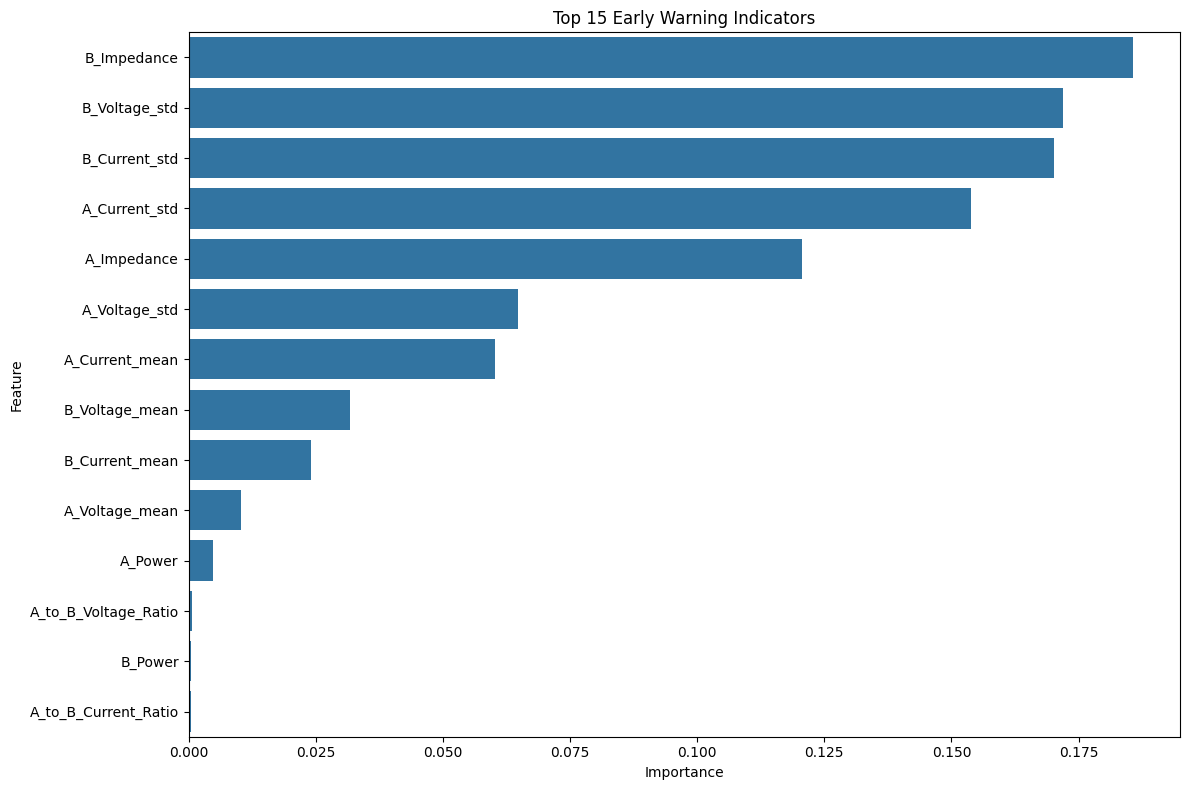


Top 10 Early Warning Indicators:
1. B_Impedance: 0.1857
2. B_Voltage_std: 0.1719
3. B_Current_std: 0.1702
4. A_Current_std: 0.1539
5. A_Impedance: 0.1206
6. A_Voltage_std: 0.0649
7. A_Current_mean: 0.0603
8. B_Voltage_mean: 0.0318
9. B_Current_mean: 0.0241
10. A_Voltage_mean: 0.0102

B_Impedance:
  Normal mean: 2.2527
  Warning threshold: 1.8302
  Critical threshold: 1.6189

B_Voltage_std:
  Normal mean: 8.9628
  Warning threshold: 12.7670
  Critical threshold: 14.6692

B_Current_std:
  Normal mean: 5.9720
  Warning threshold: 8.3641
  Critical threshold: 9.5601

A_Current_std:
  Normal mean: 5.0657
  Warning threshold: 7.0484
  Critical threshold: 8.0398

A_Impedance:
  Normal mean: 2.2057
  Warning threshold: 1.7895
  Critical threshold: 1.5814

A_Voltage_std:
  Normal mean: 9.9764
  Warning threshold: 14.1066
  Critical threshold: 16.1717

A_Current_mean:
  Normal mean: 100.2008
  Warning threshold: 119.7918
  Critical threshold: 129.5873

B_Voltage_mean:
  Normal mean: 214.1526
  

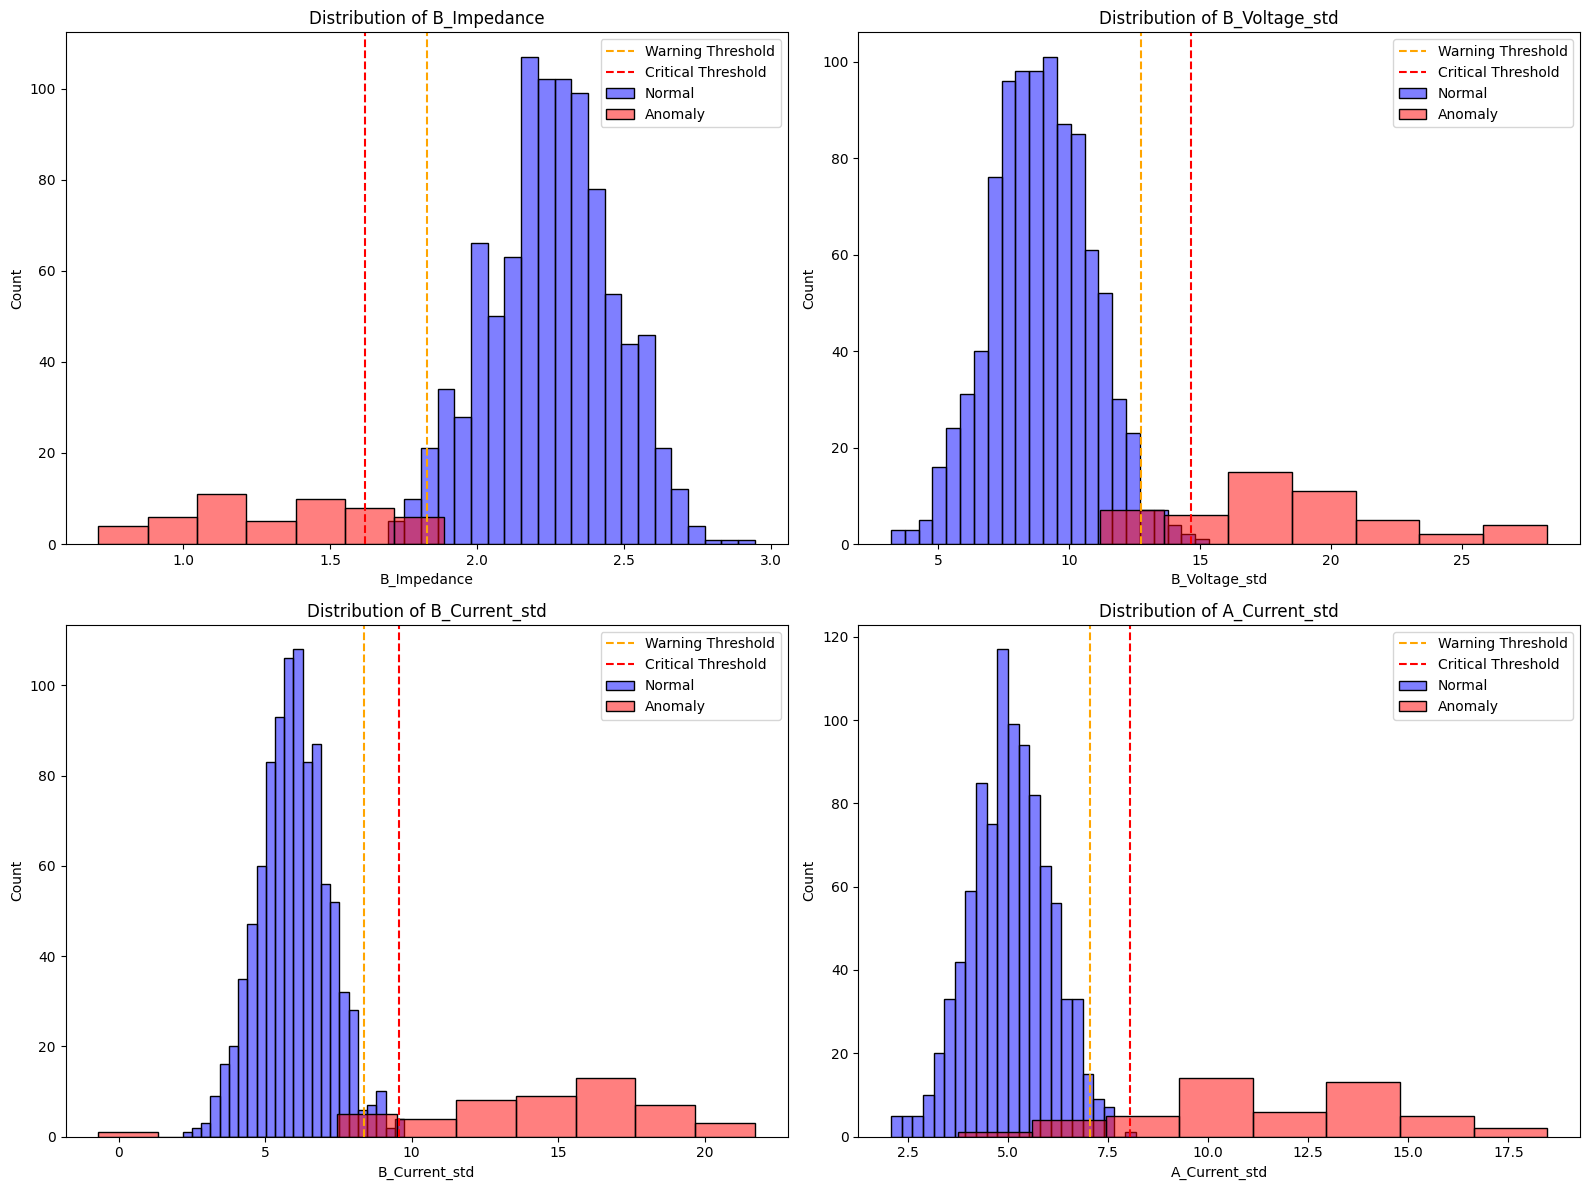

Sample data for prediction:
     A_Current_mean  A_Current_std  A_Voltage_mean  A_Voltage_std  \
764       87.553453       4.196821      244.893592       9.247399   
131       94.690030       5.021312      215.910576       9.554559   
213       94.771400       4.962963      246.829518       9.699514   
496       86.955305       4.634678      176.933142       7.585957   
510       92.923305       4.337099      213.645698      11.144781   

     B_Current_mean  B_Current_std  B_Voltage_mean  B_Voltage_std  \
764       90.380685       4.914063      230.425560      10.167987   
131       92.247412       6.550793      225.472072       8.676685   
213       86.204373       6.232055      214.255930       9.351726   
496       95.302530       3.784112      225.633398      10.215247   
510      100.383629       6.585330      225.846445       8.355617   

     A_Impedance  B_Impedance       A_Power       B_Power  \
764     1.888113     2.376229  21441.279555  20826.020002   
131     2.266474    

In [40]:
model, scaler, thresholds, warning_system = run_early_warning_system()